# -----------------------   Face_Mask_Detection   -----------------------
  

##

## Install Libraries

In [ ]:
!pip install kagglehub
!pip install tensorflow
!pip install tqdm

## Loading Libraries

In [23]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm   # for visualization specially for looping

import kagglehub # to connect tensorflow with kaggle 


## Loading Dataset

In [2]:
path = kagglehub.dataset_download("omkargurav/face-mask-dataset")
print("Dataset path:", path)


Dataset path: C:\Users\Dell\.cache\kagglehub\datasets\omkargurav\face-mask-dataset\versions\1


## Dataset Exploration

###  Checking folders and inside where image is present

    📁 **Dataset**

      data
       ├── 📂 with_mask
       │   ├── 🖼️ image1.jpg
       │   ├── 🖼️ image2.jpg
       │   └── ...
       │
       └── 📂 without_mask
           ├── 🖼️ image1.jpg
           ├── 🖼️ image2.jpg
           └── ...

In [3]:
os.listdir(path)


['data']

In [4]:
data_path = os.path.join(path, "data")
os.listdir(data_path)

['without_mask', 'with_mask']

In [5]:
# Define Image size

IMG_SIZE = 64

## Converting the image in form of x(image) and y(label) 

In [6]:
X = []
y = []

categories = ["with_mask", "without_mask"]

for category in categories:
    folder_path = os.path.join(data_path, category)
    label = categories.index(category)
    
    for img_name in tqdm(os.listdir(folder_path)): # Here you use tqdm that's why you are able to visulaize the loop in the output
        img_path = os.path.join(folder_path, img_name)
        
        img = cv2.imread(img_path)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        
        X.append(img)
        y.append(label)


100%|█████████████████████| 3828/3828 [00:08<00:00, 475.12it/s]


## Converting images and labels into array 

In [7]:
X = np.array(X)
y = np.array(y)

## Scaling or Normalization 

In [8]:
X = X / 255.0

## Checking shape of the image and label

In [9]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7553, 64, 64, 3)
y shape: (7553,)


## Dividing the training and testing data -( Train-Test Split )

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\utils\_param_validation.py:14: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.0)
  from scipy.sparse import csr_matrix, issparse


In [ ]:
!pip install --upgrade protobuf==6.31.1


## Defining the cnn model architecture

In [11]:


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Input

model = Sequential()

model.add(Input(shape=(64,64,3)))

model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))


In [ ]:
!pip show protobuf
!pip show tensorflow


## Compile the model

In [12]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


## Train the Model

In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.8482 - loss: 0.3471 - val_accuracy: 0.9179 - val_loss: 0.2084
Epoch 2/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.9186 - loss: 0.2028 - val_accuracy: 0.9305 - val_loss: 0.1756
Epoch 3/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.9374 - loss: 0.1598 - val_accuracy: 0.9365 - val_loss: 0.1729
Epoch 4/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.9542 - loss: 0.1175 - val_accuracy: 0.9457 - val_loss: 0.1440
Epoch 5/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.9684 - loss: 0.0862 - val_accuracy: 0.9504 - val_loss: 0.1502


## Evaluating the Model

In [14]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9504 - loss: 0.1502
Test Accuracy: 0.9503639936447144


## Saving the Model

In [15]:
model.save("face_mask_model.keras")


## Test on custom Image

#### Custom Prediction 1

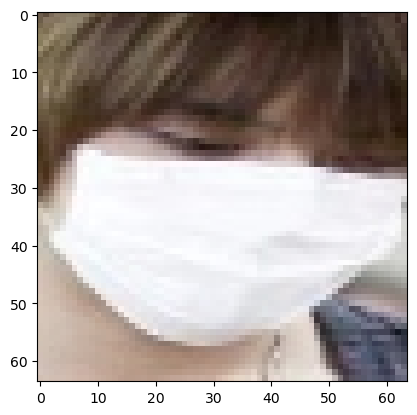

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
With Mask


In [16]:
img = cv2.imread("with_mask_93.jpg")
img = cv2.resize(img, (64,64))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

img = img / 255.0
img = np.reshape(img, (1,64,64,3))

prediction = model.predict(img)

if prediction[0][0] > 0.5:
    print("Without Mask")
else:
    print("With Mask")


#### Custom Prediction 2

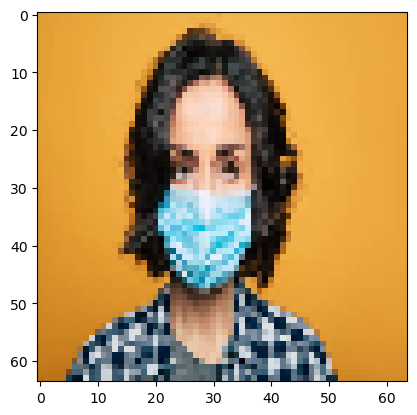

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
With Mask


In [17]:
img = cv2.imread("mask.jpg")
img = cv2.resize(img, (64,64))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

img = img / 255.0
img = np.reshape(img, (1,64,64,3))

prediction = model.predict(img)

if prediction[0][0] > 0.5:
    print("Without Mask")
else:
    print("With Mask")


#### Custom Prediction 3

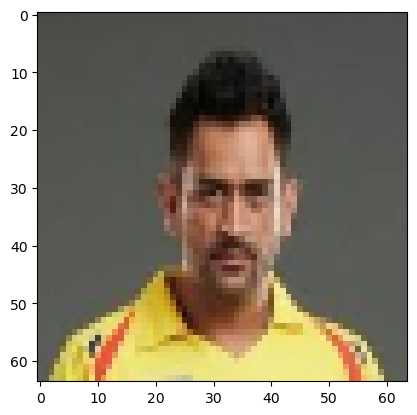

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Without Mask


In [19]:
img = cv2.imread("thala.jpg")
img = cv2.resize(img, (64,64))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

img = img / 255.0
img = np.reshape(img, (1,64,64,3))

prediction = model.predict(img)

if prediction[0][0] > 0.5:
    print("Without Mask")
else:
    print("With Mask")


## Test on Webcam Video

In [24]:
cap = cv2.VideoCapture(0)

while True:
    
    ret, frame = cap.read()
    if not ret:
        break
    
    img = cv2.resize(frame, (64,64))
    img = img / 255.0
    img = np.reshape(img, (1,64,64,3))
    
    prediction = model.predict(img)
    
    label = "Mask" if prediction[0][0] < 0.5 else "No Mask"
    
    cv2.putText(frame, label, (50,50),
                cv2.FONT_HERSHEY_SIMPLEX,
                1, (0,255,0), 2)
    
    cv2.imshow("Webcam", frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━

##

# Using HAAR Cascasde + Our CNN Model -  Webcam

##

In [22]:
cap = cv2.VideoCapture(0)

# Ensure the classifier is loaded correctly here too
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    # Haar Cascade requires grayscale images
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60))
    
    for (x, y, w, h) in faces:
        # Isolate the face
        face_crop = frame[y:y+h, x:x+w]
        
        # Format the face crop for your CNN model
        img_input = cv2.resize(face_crop, (64, 64))
        img_input = img_input / 255.0
        img_input = np.reshape(img_input, (1, 64, 64, 3))
        
        # Predict mask presence
        prediction = model.predict(img_input, verbose=0)
        raw_score = prediction[0][0]
        
        if raw_score > 0.5:
            label = "No Mask"
            confidence = raw_score * 100
            color = (0, 0, 255)  # Red box
        else:
            label = "Mask"
            confidence = (1 - raw_score) * 100
            color = (0, 255, 0)  # Green box
            
        text = f"{label}: {confidence:.2f}%"
        
        # Draw target geometry on real-time frame
        cv2.rectangle(frame, (x, y), (x+w, y+h), color, 2)
        cv2.putText(frame, text, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    
    cv2.imshow("Real-Time Face Mask Detection", frame)
    
    # Press 'q' to break the video loop safely
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

##